# Instamatic - controller
### Basics

The controller is the central part of Instamatic responsible for its interoperability. On one side, it allows any experiment to control the microscope using standardized set of keywords. On the other, it informs individual implementations what is expected from them to support the software correctly. In a proper Instamatic installation, the controller can be used directly by calling `instamatic.controller` in the command line. This opens a new interactive python shell where a `ctrl` object is already imported and ready to use. In a running python kernel without the controller running, it can be imported and initialized directly from the package:

In [1]:
from instamatic import controller

ctrl = controller.initialize()

Config directory: C:\Users\tchon\AppData\Roaming\instamatic\config
Microscope: emulator (server)
Connected to TEM server (localhost:5000)
Camera    : emulator (server)
Connected to CAM server (localhost:5001)
Use shared memory: True

Mode: mag1
High tension: 200 kV
Current density: 100529.67 pA/cm2
GunShift(x=3530, y=19881)
GunTilt(x=47235, y=30879)
BeamShift(x=10767, y=8415)
BeamTilt(x=9446, y=54663)
ImageShift1(x=42204, y=19428)
ImageShift2(x=26011, y=1205)
DiffShift(x=24123, y=5292)
Stage(x=49199, y=71752, z=71, a=5.0, b=8.0)
Magnification(value=25000, index=10)
DiffFocus(value=n/a)
Brightness(value=34309)
SpotSize(1)
Saved alignments: ('FastADT_diff', 'FastADT_image', 'FastADT_track', 'neutral')


Once it is properly initialized and connected, the controller reports the state of the microscope to the user. Internally, the report is simply a string representation of the controller and most of the lines in the report are simply minor interface objects nested inside. To get the better idea about the controller (or any Python object, in general) you can use call a built-in functions `dir` with the object as an argument, or access its documentation hidden in a dunder method `__doc__`:

In [2]:
print(ctrl.__doc__)
print(dir(ctrl))

TEMController object that enables access to all defined microscope
controls.

tem: Microscope control object (e.g. instamatic/TEMController/simu_microscope.SimuMicroscope)
cam: Camera control object (see instamatic.camera) [optional]

['MOVIE_HEADER_KEYS_COMMON', 'MOVIE_HEADER_KEYS_VARIABLE', '__class__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__firstlineno__', '__format__', '__ge__', '__getattribute__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__lt__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__sizeof__', '__static_attributes__', '__str__', '__subclasshook__', '__weakref__', '_executor', '_saved_alignments', 'acquire_at_items', 'align_to', 'autoblank', 'beam', 'beamshift', 'beamtilt', 'brightness', 'cam', 'close', 'current_density', 'difffocus', 'diffshift', 'find_eucentric_height', 'from_dict', 'get_future_image', 'get_image', 'get_movie', 'get_raw_image', 'get_rotated_i

Let's use the same functionality build ourselves a quick lookup list of the methods and objects inside the controller:

In [3]:
def document(something):
    for attr_name in dir(something):
        attr = getattr(something, attr_name)
        doc = d if (d := attr.__doc__) else 'Not documented'
        print(f'{attr_name:25s} {type(attr)!s:10}, {doc.split('\n')[0].strip()}')

document(ctrl)

MOVIE_HEADER_KEYS_COMMON  <class 'tuple'>, Built-in immutable sequence.
MOVIE_HEADER_KEYS_VARIABLE <class 'tuple'>, Built-in immutable sequence.
__class__                 <class 'type'>, TEMController object that enables access to all defined microscope
__delattr__               <class 'method-wrapper'>, Implement delattr(self, name).
__dict__                  <class 'dict'>, dict() -> new empty dictionary
__dir__                   <class 'builtin_function_or_method'>, Default dir() implementation.
__doc__                   <class 'str'>, str(object='') -> str
__eq__                    <class 'method-wrapper'>, Return self==value.
__firstlineno__           <class 'int'>, int([x]) -> integer
__format__                <class 'builtin_function_or_method'>, Default object formatter.
__ge__                    <class 'method-wrapper'>, Return self>=value.
__getattribute__          <class 'method-wrapper'>, Return getattr(self, name).
__getstate__              <class 'builtin_function_or_meth

The list starts from some class `CONSTANTS`, `__dunder__` a.k.a. `__magic__`, and `_private` methods that govern the general object behavior. Regular named public attributes intended to be accessed by the user are listed below. Some of these are methods, i.e. functions defined within controller the class, not hidden inside another namespace or interfaced by any additional proxy. Other are custom objects or properties i.e. objects that behave like simple variables but trigger additional behavior when set or get.

### Getting an image
As an example of a controller method, let's take a look at the source (documentation and code) of method `get_image`:


In [4]:
import inspect
from textwrap import dedent

print(dedent(inspect.getsource(ctrl.get_image)))

@requires_cam_attr
def get_image(
    self,
    exposure: float = None,
    binsize: int = None,
    comment: str = '',
    out: str = None,
    plot: bool = False,
    verbose: bool = False,
    header_keys: Tuple[str] = ('all',),
) -> Tuple[np.ndarray, dict]:
    """Retrieve image as numpy array from camera. If the exposure and
    binsize are not given, the default values are read from the config
    file.

    Parameters
    ----------
    exposure: float
        Exposure time in seconds
    binsize: int
        Binning to use for the image, must be 1, 2, or 4, etc.
    comment: str
        Arbitrary comment to add to the header file under 'ImageComment'
    out: str
        Path or filename to which the image/header is saved (defaults to tiff)
    plot: bool
        Toggle whether to show the image using matplotlib after acquisition
    full_header: bool
        Return the full header

    Returns
    -------
    image: np.ndarray, headerfile: dict
        Tuple of the image as nu

Let's analyze the output in detail to get a better understanding how the program is written and operates.

To begin withMethod `ctrl.get_image` is the primary way to collect information from the camera. It makes no sense whatsoever to call for an image if we have no camera, so it is quite natural the whole method is protected from a situation where camera does not initialize via a `@requires_cam_attr` decorator. The decorator simply asserts that `ctrl.cam` i.e. the camera object that we interface here, is initialized. If you are intereted how it works, you can `from instamatic.controller import requires_cam_attr` and then inspect it.

Then in the method's header we define its name and accepted attributes. We can see that when requesting image we can ask for specific `exposure` or `binsize`, request a `comment` or any specific `header_keys` to be present in the header, immediately write the image `out` etc. However, all the attributes have default values already defined, meaning that we can just as well call the method as-is, without any further parametrization:

In [5]:
ctrl.get_image()

(array([[61446, 61445, 61443, ..., 61446, 61448, 61444],
        [61446, 61445, 61441, ..., 61441, 61441, 61449],
        [61441, 61444, 61441, ..., 61446, 61444, 61443],
        ...,
        [22372, 22373, 22379, ..., 61443, 61442, 61441],
        [22379, 22372, 22376, ..., 61449, 61449, 61447],
        [22372, 22373, 22374, ..., 61443, 61441, 61447]],
       shape=(516, 516), dtype=uint32),
 {'FunctionMode': 'mag1',
  'GunShift': DeflectorTuple(x=3530, y=19881),
  'GunTilt': DeflectorTuple(x=47235, y=30879),
  'BeamShift': DeflectorTuple(x=10767, y=8415),
  'BeamTilt': DeflectorTuple(x=9446, y=54663),
  'ImageShift1': DeflectorTuple(x=42204, y=19428),
  'ImageShift2': DeflectorTuple(x=26011, y=1205),
  'DiffShift': DeflectorTuple(x=24123, y=5292),
  'StagePosition': StagePositionTuple(x=49199, y=71752, z=71, a=5.0, b=8.0),
  'Magnification': 25000,
  'Brightness': 34309,
  'SpotSize': 1,
  'ImageGetTimeStart': 524527.3246644,
  'ImageGetTimeEnd': 524527.5329939,
  'ImageGetTime': 177

Just as the return type hint `-> Tuple[np.ndarray, dict]` suggests, when called, the method returns a tuple i.e. an immutable sequence of two elements: a `np.ndarray` and a dictionary that hold the image and its header (metadata), respectively. Based on the dictionary's content and a slow evaluation of the implementation, we can see that `ctrl.get_image` does much more than just grabbing the most recent image from the camera. In particular, it interfaces the microscope as well as the camera to support the numerical array with the exact conditions of how the image was taken. By default, this information will be put into the tiff file once the image is saved:

In [6]:
import tempfile
import os

with tempfile.TemporaryDirectory() as tmpdir:
    tiff_path = os.path.join(tmpdir, 'image.tiff')
    _ = ctrl.get_image(out=tiff_path)
    with open(tiff_path, 'rb') as f:
        raw_bytes = f.read(1500)
    print(raw_bytes.decode('latin-1'))

II*                                          Â       P                          @@     v      ~  (       1          BeamShift: !!python/object/new:instamatic.microscope.components.deflectors.DeflectorTuple
- 10767
- 8415
BeamTilt: !!python/object/new:instamatic.microscope.components.deflectors.DeflectorTuple
- 9446
- 54663
Brightness: 34309
DiffShift: !!python/object/new:instamatic.microscope.components.deflectors.DeflectorTuple
- 24123
- 5292
FunctionMode: mag1
GunShift: !!python/object/new:instamatic.microscope.components.deflectors.DeflectorTuple
- 3530
- 19881
GunTilt: !!python/object/new:instamatic.microscope.components.deflectors.DeflectorTuple
- 47235
- 30879
ImageBinsize: 1
ImageCameraDimensions: [516, 516]
ImageCameraName: emulator
ImageComment: ''
ImageExposureTime: 0.1
ImageGetTime: 1779958953.2033367
ImageGetTimeEnd: 524527.8440842
ImageGetTimeStart: 524527.6607586
ImageResolution: [516, 516]
ImageS

As for the image itself, we can easily investigate it using `matplotlib.pyplot`. If you can't see anything, try uncommenting the remaining line to decrease the magnification:

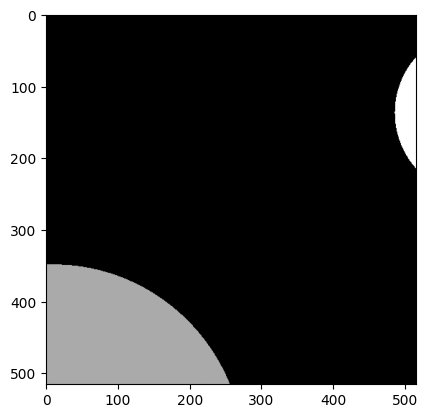

In [7]:
from matplotlib import pyplot as plt

# ctrl.magnification.set(2500)
image, _ = ctrl.get_image()
plt.imshow(image, cmap='gray_r')
plt.show()

### Interfacing camera directly
`ctrl.get_image` is the most common and comprehensive way to access the current view from the camera. By default, it triggers a long list of functionalities and is atomic i.e. puts a single request for a single image, waits, receives an image, collects metadata, and returns the whole packet at once. If you do not need a full image, or you need multiple images, and you want to decrease the dead time by accessing the camera more directly, then you can do so in two ways. The more direct one is by accessing and getting the image from the camera directly:

In [8]:
print(ctrl.cam.get_image())

[[61449 61444 61447 ... 61448 61447 61443]
 [61441 61441 61449 ... 61448 61447 61443]
 [61444 61444 61442 ... 61443 61444 61447]
 ...
 [22374 22377 22379 ... 61445 61444 61449]
 [22371 22375 22373 ... 61444 61447 61441]
 [22374 22375 22377 ... 61446 61447 61447]]


Instead of accessing the controller implementation of `get_image` as we did previously, this method calls the camera implementation of this method *more* directly. This may look very similar, but is diametrically different. Rather than letting the generic controller do all the work for us (scaling, corrections, metadata) we just access the `ctrl.cam` object and execute its `get_image`. Critically, unless we work in the most straightforward local simulator that only creates noise, `ctrl.cam` is NOT our camera: it is a wrapper about an ongoing live image stream that itself accesses its `.cam`, a proxy object that serializes ("packs up") our request, passes it via the network, waits for the result, reads the result from the connection, de-serializes it, and returns just as if we accessed the object directly:

In [9]:
print(type(ctrl.cam))
print(dir(ctrl.cam))
print()
print(type(ctrl.cam.cam))
print(dir(ctrl.cam.cam))

<class 'instamatic.camera.videostream.LiveVideoStream'>
['__class__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__firstlineno__', '__format__', '__ge__', '__getattr__', '__getattribute__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__lt__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__sizeof__', '__static_attributes__', '__str__', '__subclasshook__', '__weakref__', '_after_fork', '_args', '_bootstrap', '_bootstrap_inner', '_daemonic', '_delete', '_handle', '_ident', '_initialized', '_invoke_excepthook', '_kwargs', '_name', '_native_id', '_set_ident', '_set_native_id', '_started', '_stderr', '_target', 'block', 'blocked', 'cam', 'close', 'daemon', 'default_binsize', 'default_exposure', 'dimensions', 'frame', 'frametime', 'from_any', 'getName', 'get_image', 'get_movie', 'grabber', 'ident', 'isDaemon', 'is_alive', 'join', 'lock', 'name', 'native_id', 'requested', 'run', 'send_media'

For its server-client communication, the current version of instamatic is using a very barebones communication scheme, where requests are passed as tuples of (method name, positional arguments, keyword arguments), while responses as tuples of (Response code, return value). If you are interested in its intricacies, check out the implementation in the following files:
* `instamatic/camera/camera_client.py`
* `instamatic/microscope/client.py`
* `instamatic/server/cam_server.py`
* `instamatic/server/tem_server.py`

### Collecting a movie
The second, far less popular way to access camera image via the controller is using `ctrl.get_movie`. In contrast to its atomic counterpart, the movie method focuses on getting a short burst of consecutive frames with minimum time inbetween them. The implementation of `get_movie` varies between cameras but should optimally limit the dead time between expositions to the minimum; in case of the emulator, it should be zero. The dead time can be set in camera config or calibrated using `instamatic.calibrate_movie_delay`. For the time being let's focus on its signature:

In [10]:
import inspect

print(inspect.signature(ctrl.get_movie))

(n_frames: 'int', exposure: 'float' = None, binsize: 'int' = None, comment: 'str' = '', header_keys: 'Tuple[str]' = ('BeamShift', 'BeamTilt', 'StagePosition'), header_keys_common: 'Tuple[str]' = ('FunctionMode', 'GunShift', 'GunTilt', 'ImageShift1', 'ImageShift2', 'DiffShift', 'Magnification', 'DiffFocus', 'Brightness', 'SpotSize')) -> 'Generator[np.ndarray, None, None]'


Apart from the first attribute `n_frames`, the input parameters of `get_movie` and `get_image` largely align. However, rather than returning a raw image, this method returns a generator that yields an image-header pair as soon as one it is available (note that the documentation here is slightly wrong). The benefit of this solution is that many cameras work faster when they are asked for N images rather than 1 image N times. The generator can also work in a separate thread without affecting the responsiveness of the GUI, allowing for other operations (e.g. beam or stage shift) to be done at the same time, etc. The camera starts collecting the movie not when the generator is created, but rather whenever the first image is requested:

In [19]:
from time import sleep
from datetime import datetime

movie = ctrl.get_movie(n_frames=5, exposure=1.0)
print(f'Created the initial movie generator at {datetime.now()}.')
sleep(3)  # simulates some complicated setup at the microscope

print(f'Finished some complicated TEM setup at {datetime.now()}.')
for image, header in movie:
    t = datetime.fromtimestamp(header['ImageGetTime'])
    print(f'Got an image with shape {image.shape} at  {t}.')

Created the initial movie generator at 2026-05-28 11:03:16.444876.
Finished some complicated TEM setup at 2026-05-28 11:03:19.445334.
Got an image with shape (516, 516) at  2026-05-28 11:03:20.647375.
Got an image with shape (516, 516) at  2026-05-28 11:03:21.648948.
Got an image with shape (516, 516) at  2026-05-28 11:03:22.650800.
Got an image with shape (516, 516) at  2026-05-28 11:03:23.653735.
Got an image with shape (516, 516) at  2026-05-28 11:03:24.654893.


### TEM control
Let's explore some other functionality of the controller. Similarly to how, the camera can be interfaced (more) directly via `ctrl.cam`, the functionality of the microscope is mostly available under `ctrl.tem`. However, most of the settings of interest should be available directly from the level of controller. For example, the spot size can be get and set via a dedicated property:

In [12]:
ss = ctrl.spotsize
print(ss)
ctrl.spotsize = ss

1


This is completely equivalent to the following:

In [13]:
ss = ctrl.tem.getSpotSize()
print(ss)
ctrl.tem.setSpotSize(ss)

1


If we look up the particular implementation of our simulated TEM, available at `instamatic/microscope/interface/simu_microscope.py`, then this is also theoretically equivalent to accessing the simulated TEM running in the emulator directly and setting or getting its internal variable:

In [14]:
# DO NOT UNCOMMENT AND RUN
# ss = ctrl.tem.spotsize
# ctrl.tem.spotsize = ss

However, the latter is strongly discouraged and can straight up break the functionality if working via the network. Even if it works, the code produced this way will work only on a TEM that supports this syntax. In practice, unless strictly necessary, microscope-specific implementations should be never accessed directly.

Let's take a look at another example. Magnification in instamatic is controlled via the following object (adapting code used previously to inspect the controller):

In [20]:
document(ctrl.magnification)

__class__                 <class 'type'>, Magnification control.
__delattr__               <class 'method-wrapper'>, Implement delattr(self, name).
__dict__                  <class 'dict'>, dict() -> new empty dictionary
__dir__                   <class 'builtin_function_or_method'>, Default dir() implementation.
__doc__                   <class 'str'>, str(object='') -> str
__eq__                    <class 'method-wrapper'>, Return self==value.
__firstlineno__           <class 'int'>, int([x]) -> integer
__format__                <class 'builtin_function_or_method'>, Default object formatter.
__ge__                    <class 'method-wrapper'>, Return self>=value.
__getattribute__          <class 'method-wrapper'>, Return getattr(self, name).
__getstate__              <class 'builtin_function_or_method'>, Helper for pickle.
__gt__                    <class 'method-wrapper'>, Return self>value.
__hash__                  <class 'method-wrapper'>, Return hash(self).
__init__              

Within the object, magnification can be modified in many different ways: relative to the current selection (`increase` / `decrease`), using absolute index (`index`), or by setting it to the intuitive magnification label (`set`):

In [16]:
print('Changing relative magnification')
print(ctrl.magnification)
ctrl.magnification.increase()
print(ctrl.magnification)
ctrl.magnification.decrease()
print(ctrl.magnification)

print('Changing absolute magnification')
print(ctrl.magnification)
idx = ctrl.magnification.index
ctrl.magnification.index = idx + 1
print(ctrl.magnification)
ctrl.magnification.index = idx
print(ctrl.magnification)

print('Changing magnification using labels')
print(ctrl.magnification)
mag = ctrl.magnification.get()
ctrl.magnification.set(4000)
print(ctrl.magnification)
ctrl.magnification.set(mag)
print(ctrl.magnification)

Changing relative magnification
Magnification(value=25000, index=10)
Magnification(value=30000, index=11)
Magnification(value=25000, index=10)
Changing absolute magnification
Magnification(value=25000, index=10)
Magnification(value=30000, index=11)
Magnification(value=25000, index=10)
Changing magnification using labels
Magnification(value=25000, index=10)
Magnification(value=4000, index=2)
Magnification(value=25000, index=10)


Under the hood, these functions rely on several other more verbose methods that need to be implemented individually by every microscope; however, the interface revealed to the user by this proxy object is designed to be as simple and general as possible. Neither the user, nor ever experiment designer, (only the person implementing the TEM interface) should be ever concerned about the exact shape of these methods:
* `ctrl.tem.getMagnification`
* `ctrl.tem.setMagnification`
* `ctrl.tem.getMagnificationIndex`
* `ctrl.tem.setMagnificationIndex`
* `ctrl.tem.getMagnificationAbsoluteIndex`
* `ctrl.tem.getMagnificationRanges`

The reader is encouraged to explore other objects forming the total controller interface. However, one should mind that when working on the emulator i.e. using the simulated TEM, several values might be only implemented to match the total interface and may be otherwise completely meaningless:

In [17]:
ctrl_member_names = ['acquire_at_items', 'align_to', 'autoblank', 'beam', 'beamshift', 'beamtilt', 'brightness', 'cam', 'close', 'current_density', 'difffocus', 'diffshift', 'find_eucentric_height', 'from_dict', 'get_future_image', 'get_image', 'get_movie', 'get_raw_image', 'get_rotated_image', 'get_stagematrix', 'grid_montage', 'gunshift', 'guntilt', 'high_tension', 'imageshift1', 'imageshift2', 'magnification', 'mode', 'restore', 'run_script', 'run_script_at_items', 'screen', 'show_stream', 'spotsize', 'stage', 'stageposition', 'store', 'store_diff_beam', 'tem', 'to_dict']
print(ctrl.imageshift1)
print(ctrl.mode)
print(ctrl.to_dict())

ImageShift1(x=42204, y=19428)
Mode('mag1')
{'FunctionMode': 'mag1', 'GunShift': DeflectorTuple(x=3530, y=19881), 'GunTilt': DeflectorTuple(x=47235, y=30879), 'BeamShift': DeflectorTuple(x=10767, y=8415), 'BeamTilt': DeflectorTuple(x=9446, y=54663), 'ImageShift1': DeflectorTuple(x=42204, y=19428), 'ImageShift2': DeflectorTuple(x=26011, y=1205), 'DiffShift': DeflectorTuple(x=24123, y=5292), 'StagePosition': StagePositionTuple(x=49199, y=71752, z=71, a=5.0, b=8.0), 'Magnification': 25000, 'Brightness': 34309, 'SpotSize': 1}


### Stage control
Finally, the most advanced and complicated object available at the TEM side of the controller interface is `ctrl.stage`. The stage is responsible for any movement of the sample, and reveals a plethora of methods for moving the grid synchronously or asynchronously:

In [21]:
document(ctrl.stage)

__class__                 <class 'type'>, Stage control.
__delattr__               <class 'method-wrapper'>, Implement delattr(self, name).
__dict__                  <class 'dict'>, dict() -> new empty dictionary
__dir__                   <class 'builtin_function_or_method'>, Default dir() implementation.
__doc__                   <class 'str'>, str(object='') -> str
__eq__                    <class 'method-wrapper'>, Return self==value.
__firstlineno__           <class 'int'>, int([x]) -> integer
__format__                <class 'builtin_function_or_method'>, Default object formatter.
__ge__                    <class 'method-wrapper'>, Return self>=value.
__getattribute__          <class 'method-wrapper'>, Return getattr(self, name).
__getstate__              <class 'builtin_function_or_method'>, Helper for pickle.
__gt__                    <class 'method-wrapper'>, Return self>value.
__hash__                  <class 'method-wrapper'>, Return hash(self).
__init__                  <cla

The current state of the stage can be read and controlled using dedicated properties = setters/getters, `ctrl.stage.x`, `y`, `z`, `a`, `b`, `xy`, or dedicated methods such as `set`. Some method are designed to move the stage relative to current position: `move_xy`, `move_in_projection`, `move_along_optical_axis`. Other eliminate backlash correction i.e. the lack of accuracy when approaching given position from one versus another direction: `set_xy_with_backlash_correction`, `eliminate_backlash_xy`. Stage speed, if allowed by the hardware, can be configured using `set_with_speed`, `set_a_with_speed`, `set_rotation_speed`, or just `set` with `speed` attribute. Finally, some methods allow for more complex functionality (`alpha_wobbler`), combined workflows (`move_xy_with_backlash_correction`, `with rotation_speed`), or flow control (`wait`, `is_moving`).

### Output and units
There is a lot of distinct methods in the entirety of Instamatic designed to work in different cases, therefore keeping the units consistent and well understandable is a challenge of its own. The gist of this subject is that most of the units used inside the controller are consistent and based on two units. Distances are typically expressed in nanometers using built-in python integers, while angles are usually expressed in degrees using built-in python floats. The precision achieved by the TEM supported by Instamatic is rarely below 1 nanometer, but must stay constant whether the stage is in the very center or far right. As for the angles, expressing then using a floating point units is simply much more convenient and intuitive, and precision of Python's 64-bit float at 90 degrees is way below 10^-15, more than enough.

The units become more complicated when it comes to the electron optics and currents. In that case, the values may be expressed in different units and differ largely between Jeol and Tecnai machines. This is not of a particular concern since they are consistent on one given machine and are mostly use to "store" or "restore" controller state. Whenever possible, the Tecnai values are rescaled to approximately match the Jeol standard (since this is the original system Instamatic was developed on). If possible, it is important not to rely on absolute values of these elements, but rather save and restore them from previous experiments or calibrations.

## Exercise
Given everything mentioned above, the following is an exercise suggested to the participant. Design a simple experiment that would run, starting from the current position of the stage (can be set using GUI). For a small challange, write a RED experiment (collect static diffraction data every certain tilt angle). For a bigger challenge incorporating multithreading, design a cRED experiment where data is collected while the stage is rotating. For the greatest challange, think how could you plan for and execute other movements e.g. beam shift or intensity change during data collection.

In [ ]:
# A place to experiment!